In [2]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
class ChemicalSpecies(object):
    
    def __init__(self, name, count):
        self.name=name
        self.count=count
        

class Reaction(object):
    
    def __init__(self,reactant_list, product_list, coefficient_dic, reconstant):
        self.reactant_list=reactant_list
        self.product_list=product_list
        self.coefficient_dic=coefficient_dic
        self.reaction_constant=reconstant
        
    def get_propensity(self):
        k=1
        for i in self.reactant_list:
            k=k*i.count**self.coefficient_dic[i.name]
            
        propensity=self.reaction_constant*k
        return propensity
          
    def execute(self):
        for i in self.reactant_list:
            i.count-=self.coefficient_dic[i.name]
            
        for j in self.product_list:
            j.count+=self.coefficient_dic[j.name]
            
        return self.reactant_list,self.product_list
    
    
class System(object):
    
    def __init__(self, reaction_list, chemical_list):
        self.reaction_list=reaction_list
        self.chemical_list=chemical_list
    
    
    def run_directmethod(self,chemicals=None):
        
        rx1,rx2,rx3,rx4,rx5=self.reaction_list
        
        if chemicals==None:                 
            h,s,j,k,l,m,n=self.chemical_list 
        else:
            h,s,j,k,l,m,n=chemicals   # since i has been used, use s to replace i.

        in_equilibrium = False
        prop1=rx1.get_propensity()
        prop2=rx2.get_propensity()
        prop3=rx3.get_propensity()
        prop4=rx4.get_propensity()
        prop5=rx5.get_propensity()
        
        propensity_list=[prop1,prop2,prop3,prop4,prop5]
        
        sumprop=sum(propensity_list)
        
        prob_list=[]
        if sumprop>0:                                     
            for i in propensity_list:                    
                prob_list.append(i/sumprop)  
        elif sumprop==0:                                            
            in_equilibrium = True
        else:
            print("Error: negative propensities.")
           
        tau=0
        
        if sum(prob_list)!=0:                                 
            u=random.choice(np.arange(0,5),p=prob_list)   
            tau=random.exponential(1/sumprop)
        
            if u==0:
                [h,s],[j]=rx1.execute()
            elif u==1:
                [s,j],[k]=rx2.execute()
            elif u==2:
                [k,l],[l,m]=rx3.execute()
            elif u==3:
                [m],[k,n]=rx4.execute()
            else:
                [l,n],[h]=rx5.execute()
        
        
        species_list=[h,s,j,k,l,m,n]
#         print(species_list)

        speciescount_list=[h.count,s.count,j.count,k.count,l.count,m.count,n.count]
#         print(speciescount_list)
        
        return species_list, tau, in_equilibrium

        
        
    def stimulate(self,start_time, end_time,method):
        t0=start_time
        t_list=[start_time]
        
        chem_list=[self.chemical_list]
        
        chemcount_list=[]
        totalcount_list=[]
        
        for i in self.chemical_list:
            chemcount_list.append(i.count)
        
        totalcount_list.append(chemcount_list)
        
        equilibrium=False
        
        if method=='Directmethod':
            species_list, t, equilibrium=self.run_directmethod()
            t0+=t
            
            chemcount_list=[]
            for i in species_list:
                chemcount_list.append(i.count)
        
            totalcount_list.append(chemcount_list)
            
        else:
            pass
        
        
        if t0<end_time:
            t_list.append(t0)
            chem_list.append(species_list)
            
            while t0<end_time:
                species_list, t, equilibrium=self.run_directmethod(species_list)
                
                if t!=0:
                    t0+=t
                    t_list.append(t0)
                    chem_list.append(species_list)
                    
                    chemcount_list=[]
                    for i in species_list:
                        chemcount_list.append(i.count)
                    totalcount_list.append(chemcount_list)      

                else:
                    equilibrium=True
                    break
                
#             print(np.array(totalcount_list))
        return np.array(t_list), np.array(totalcount_list), equilibrium
    
    
    def display(self, start_time, end_time, method):
        t,c,s=self.stimulate(start_time,end_time,"Directmethod")
        print(list(zip(t,c)))
        plt.plot(t,c)
        
        
            
            
       


[(1.0, array([ 6, 14,  8, 12,  9,  3,  5])), (1.0025671557998068, array([ 6, 14,  8, 13,  9,  2,  6])), (1.0027772308826464, array([ 6, 13,  7, 14,  9,  2,  6])), (1.0058026291202693, array([ 6, 13,  7, 13,  9,  3,  6])), (1.0058603550648406, array([ 7, 13,  7, 13,  8,  3,  5])), (1.0067755933565159, array([ 7, 13,  7, 12,  8,  4,  5])), (1.0072711046852387, array([ 7, 13,  7, 11,  8,  5,  5])), (1.007660384804131, array([ 7, 12,  6, 12,  8,  5,  5])), (1.0088544531799342, array([ 6, 11,  7, 12,  8,  5,  5])), (1.0091081841635956, array([ 6, 10,  6, 13,  8,  5,  5])), (1.010103265561318, array([ 7, 10,  6, 13,  7,  5,  4])), (1.0105260249171608, array([ 7,  9,  5, 14,  7,  5,  4])), (1.0110393435662179, array([ 8,  9,  5, 14,  6,  5,  3])), (1.011805314879312, array([ 8,  8,  4, 15,  6,  5,  3])), (1.0135894908858711, array([ 8,  8,  4, 14,  6,  6,  3])), (1.013616913938973, array([ 8,  8,  4, 13,  6,  7,  3])), (1.0160034358361432, array([ 8,  8,  4, 14,  6,  6,  4])), (1.016852196161

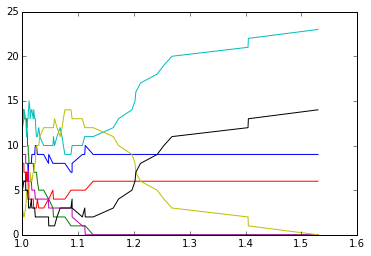

In [6]:
a=ChemicalSpecies('A',6)
b=ChemicalSpecies('B',14)
c=ChemicalSpecies('C',8)
d=ChemicalSpecies('D',12)
e=ChemicalSpecies('E',9)
f=ChemicalSpecies('F',3)
g=ChemicalSpecies('G',5)

chemical_list=[a,b,c,d,e,f,g]

rx1=Reaction([a, b],[c],{a.name:1,b.name:1,c.name:1},1)
rx2=Reaction([b, c],[d],{b.name:1,c.name:1,d.name:1},2)
rx3=Reaction([d,e],[e,f],{d.name:1,e.name:1,e.name:1,f.name:1},3)
rx4=Reaction([f],[d,g],{f.name:1,d.name:1,g.name:1},4)
rx5=Reaction([e, g],[a],{e.name:1,g.name:1,a.name:1},5)

reaction_list=[rx1,rx2,rx3,rx4,rx5]


system= System(reaction_list,chemical_list)
# s=system.run_directmethod()
# print(s)



# w=system.stimulate(1,5,'Directmethod')
# print(w)

v=system.display(1,5,'Directmethod')
print(v)
